# TFG UEx Motorsport

**Modelos activos:**
- Predicción de marcha (Random Forest + comparativa XGBoost/SVM)
- Gemelo digital de temperatura (Gradient Boosting + comparativa)
- Detección de anomalías (Isolation Forest)

> El Modelo 2 (estilo de conducción) fue eliminado: no aplica a Formula Student donde siempre se exige el 100% de rendimiento.


---
## 0. Importaciones y configuración

In [ ]:
import os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import joblib
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor, IsolationForest
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC, SVR
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    mean_absolute_error, mean_squared_error, r2_score
)

# XGBoost es opcional — si no está instalado se omite
try:
    from xgboost import XGBClassifier, XGBRegressor
    XGBOOST_OK = True
    print("XGBoost disponible")
except ImportError:
    XGBOOST_OK = False
    print("XGBoost no instalado — pip install xgboost  (se usará solo RF y SVM)")

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11
print("Librerías cargadas")


✅ XGBoost disponible
✅ Librerías cargadas


In [ ]:

# Busca todos los CSVs en la carpeta datos/ automáticamente
RUTAS_CSV = sorted(glob.glob('../datos/dataset_skoda_*.csv'))
SEP_CSV   = ';'

HZ_REAL          = 3.0
VENTANA_SEGUNDOS = 1.0
VENTANA_FILAS    = max(1, round(HZ_REAL * VENTANA_SEGUNDOS))

print(f"CSVs encontrados: {len(RUTAS_CSV)}")
for r in RUTAS_CSV:
    print(f"  {r}")
print(f"Ventana M3: {VENTANA_FILAS} filas ≈ {VENTANA_FILAS/HZ_REAL:.1f}s")


CSVs encontrados: 8
  ../datos\dataset_skoda_20260327_152347_excel.csv
  ../datos\dataset_skoda_20260327_223749.csv
  ../datos\dataset_skoda_20260328_111925.csv
  ../datos\dataset_skoda_20260328_114700.csv
  ../datos\dataset_skoda_20260328_193804.csv
  ../datos\dataset_skoda_20260329_203706.csv
  ../datos\dataset_skoda_20260330_184217.csv
  ../datos\dataset_skoda_20260331_142626.csv
Ventana M3: 3 filas ≈ 1.0s


---
## 1. Carga de datos

In [ ]:
frames = []
for ruta in RUTAS_CSV:
    try:
        _df = pd.read_csv(ruta, sep=SEP_CSV)
        _df.columns = _df.columns.str.lower().str.strip()
        _df['origen'] = os.path.basename(ruta)
        filas_antes = len(_df)

        # Descartar CSVs sin movimiento
        filas_movimiento = (_df['velocidad'] > 2).sum() if 'velocidad' in _df.columns else 0
        if filas_movimiento < 50:
            print(f"  {ruta}: solo {filas_movimiento} filas en movimiento — OMITIDO "
                  f"(útil para M4 pero no para M1/M3)")
            continue

        frames.append(_df)
        print(f"  {os.path.basename(ruta)}: {filas_antes:,} filas "
              f"({filas_movimiento} en movimiento) ✓")
    except FileNotFoundError:
        print(f"  No encontrado: {ruta}")

if not frames:
    raise RuntimeError("No hay CSVs con datos de conducción válidos. "
                       "Necesitas al menos un trayecto con el coche en movimiento.")

df = pd.concat(frames, ignore_index=True)
df['timestamp_iso'] = pd.to_datetime(df['timestamp_iso'], errors='coerce')
df['timestamp']     = pd.to_numeric(df['timestamp'], errors='coerce')
df = df.sort_values('timestamp').reset_index(drop=True)

duracion = df['timestamp'].max() - df['timestamp'].min()
hz_medio = len(df) / duracion if duracion > 0 else 0

print(f"\n Dataset total: {len(df):,} filas × {len(df.columns)} columnas")
print(f"  Duración: {duracion:.0f}s ({duracion/60:.1f} min)")
print(f" Frecuencia media: {hz_medio:.2f} Hz")
print(f"Columnas: {list(df.columns)}")
df.head()


  ⚠️  ../datos\dataset_skoda_20260327_152347_excel.csv: solo 0 filas en movimiento — OMITIDO (útil para M4 pero no para M1/M3)
  📂 dataset_skoda_20260327_223749.csv: 2,640 filas (2233 en movimiento) ✓
  📂 dataset_skoda_20260328_111925.csv: 2,117 filas (1742 en movimiento) ✓
  📂 dataset_skoda_20260328_114700.csv: 5,710 filas (5098 en movimiento) ✓
  📂 dataset_skoda_20260328_193804.csv: 4,211 filas (3468 en movimiento) ✓
  ⚠️  ../datos\dataset_skoda_20260329_203706.csv: solo 0 filas en movimiento — OMITIDO (útil para M4 pero no para M1/M3)
  📂 dataset_skoda_20260330_184217.csv: 1,643 filas (306 en movimiento) ✓
  📂 dataset_skoda_20260331_142626.csv: 2,002 filas (1415 en movimiento) ✓

📊 Dataset total: 18,323 filas × 12 columnas
⏱  Duración: 312910s (5215.2 min)
📡 Frecuencia media: 0.06 Hz
Columnas: ['timestamp', 'timestamp_iso', 'rpm', 'velocidad', 'temp_motor', 'pos_acelerador', 'carga_motor', 'origen', 'presion_map', 'avance_encendido', 'temp_admision', 'marcha']


,timestamp,timestamp_iso,rpm,velocidad,temp_motor,pos_acelerador,carga_motor,origen,presion_map,avance_encendido,temp_admision,marcha
0,1.774647e+09,2026-03-27 22:37:58.432,872.0,0.0,52.0,4.71,24.71,dataset_skoda_20260327_223749.csv,NaN,NaN,NaN,NaN
1,1.774647e+09,2026-03-27 22:37:58.626,872.0,0.0,51.0,4.71,24.71,dataset_skoda_20260327_223749.csv,NaN,NaN,NaN,NaN
2,1.774647e+09,2026-03-27 22:37:58.887,872.0,0.0,51.0,4.71,24.31,dataset_skoda_20260327_223749.csv,NaN,NaN,NaN,NaN
3,1.774647e+09,2026-03-27 22:37:59.264,871.0,0.0,51.0,4.71,24.31,dataset_skoda_20260327_223749.csv,NaN,NaN,NaN,NaN
4,1.774647e+09,2026-03-27 22:38:00.187,878.0,0.0,51.0,4.71,24.31,dataset_skoda_20260327_223749.csv,NaN,NaN,NaN,NaN


---
## 2. Exploración

In [4]:
df[['rpm','velocidad','temp_motor','pos_acelerador']].describe().round(2)


,rpm,velocidad,temp_motor,pos_acelerador
count,17014.00,17014.00,17014.00,17014.00
mean,1845.24,36.56,78.34,15.24
std,807.06,30.97,14.48,22.20
min,0.00,0.00,21.00,0.00
25%,1034.00,13.00,79.00,5.10
50%,1851.00,32.00,84.00,6.67
75%,2356.00,50.00,86.00,14.12
max,5699.00,162.00,95.00,100.00


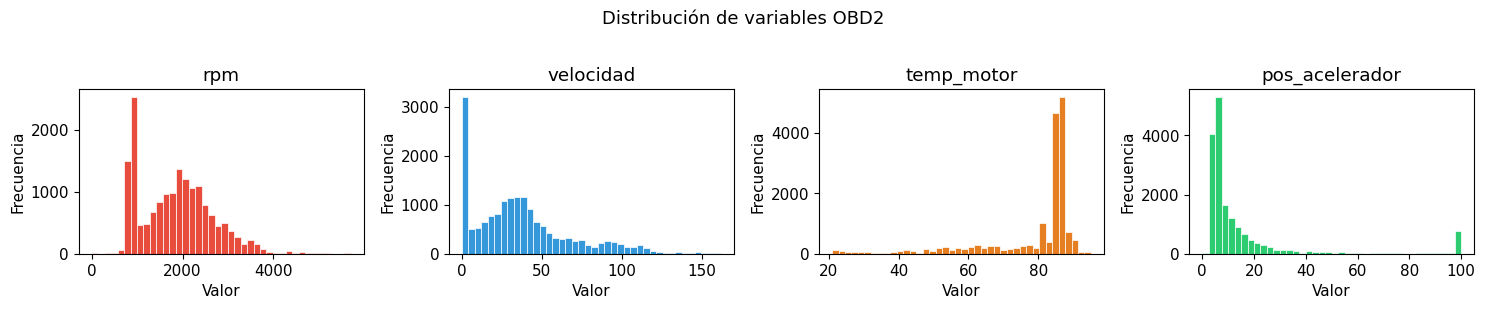

In [5]:
variables = ['rpm','velocidad','temp_motor','pos_acelerador']
colores   = ['#e74c3c','#3498db','#e67e22','#2ecc71']

fig, axes = plt.subplots(1, 4, figsize=(15, 3))
for ax, var, col in zip(axes, variables, colores):
    ax.hist(df[var].dropna(), bins=40, color=col, edgecolor='white', linewidth=0.5)
    ax.set_title(var); ax.set_xlabel('Valor'); ax.set_ylabel('Frecuencia')
plt.suptitle('Distribución de variables OBD2', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()


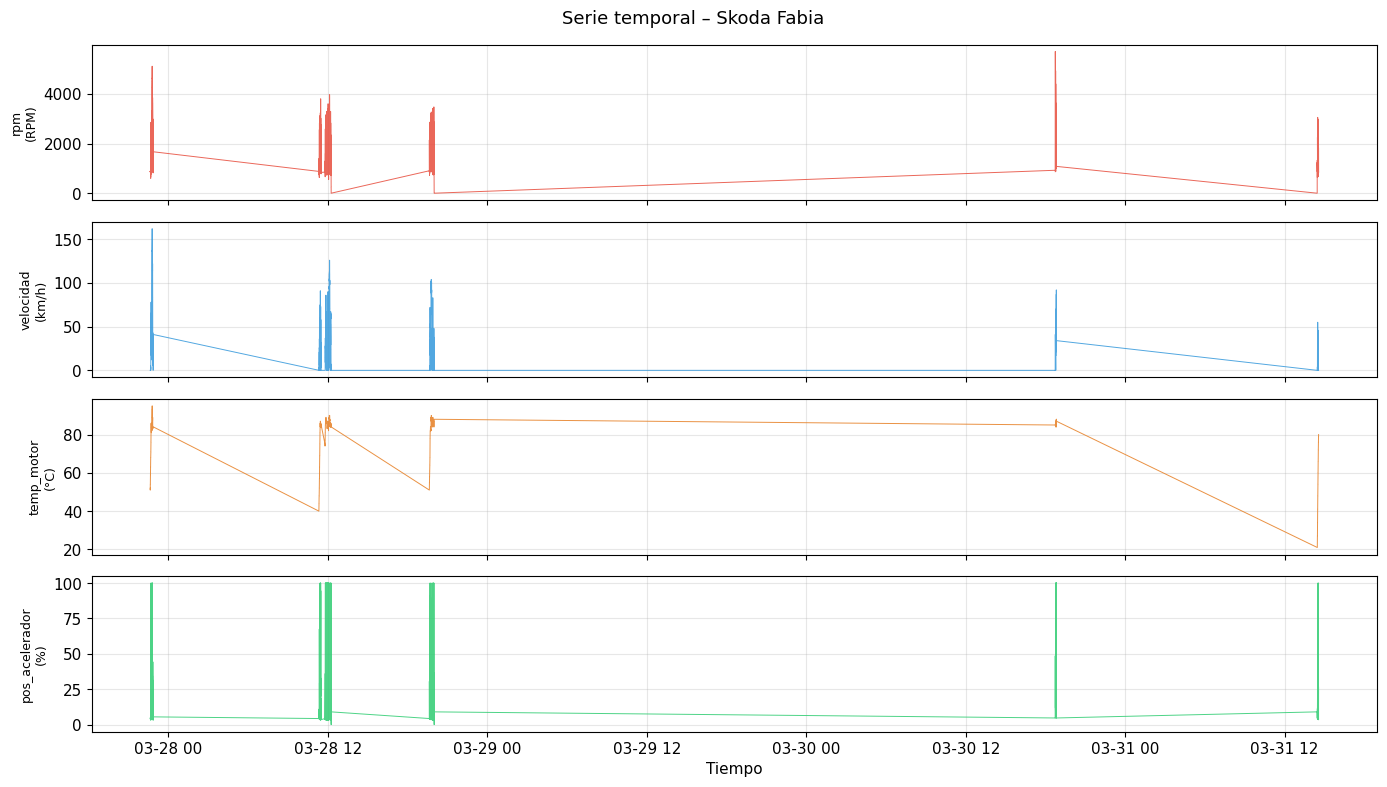

In [6]:
fig, axes = plt.subplots(4, 1, figsize=(14, 8), sharex=True)
unidades = ['RPM','km/h','°C','%']
for ax, var, col, uni in zip(axes, variables, colores, unidades):
    ax.plot(df['timestamp_iso'], df[var], color=col, linewidth=0.7, alpha=0.85)
    ax.set_ylabel(f'{var}\n({uni})', fontsize=9); ax.grid(True, alpha=0.3)
axes[-1].set_xlabel('Tiempo')
plt.suptitle('Serie temporal – Skoda Fabia', fontsize=13)
plt.tight_layout(); plt.show()


---
## 3. Limpieza de datos

In [ ]:
print("=== Valores nulos ===")
print(df.isnull().sum())

n_antes = len(df)
df = df.dropna(subset=['rpm','velocidad']).reset_index(drop=True)
df = df.drop_duplicates(subset=['timestamp']).reset_index(drop=True)
print(f"\nDuplicados/nulos eliminados: {n_antes - len(df)}")

df = df[
    (df['rpm']            >= 0)   & (df['rpm']            <= 8000) &
    (df['velocidad']      >= 0)   & (df['velocidad']      <= 250)  &
    (df['temp_motor']     >= -30) & (df['temp_motor']     <= 130)  &
    (df['pos_acelerador'] >= 0)   & (df['pos_acelerador'] <= 100)
].reset_index(drop=True)

for col in ['presion_map','avance_encendido','temp_admision']:
    if col in df.columns:
        df[col] = df[col].interpolate(limit=5).fillna(df[col].median())

# ratio RPM/velocidad 
df['ratio_rpm_vel'] = df.apply(
    lambda r: r['rpm']/r['velocidad'] if r['velocidad'] > 2 else 0, axis=1
)

print(f"Filas tras limpieza: {len(df):,}")
print(f"Columnas disponibles: {list(df.columns)}")


=== Valores nulos ===
timestamp            1601
timestamp_iso        1309
rpm                  1309
velocidad            1309
temp_motor           1309
pos_acelerador       1309
carga_motor          1309
origen                  0
presion_map         15987
avance_encendido    15987
temp_admision       17989
marcha              17989
dtype: int64

Duplicados/nulos eliminados: 1600
Filas tras limpieza: 16,723
Columnas disponibles: ['timestamp', 'timestamp_iso', 'rpm', 'velocidad', 'temp_motor', 'pos_acelerador', 'carga_motor', 'origen', 'presion_map', 'avance_encendido', 'temp_admision', 'marcha', 'ratio_rpm_vel']


---
## 4. Generación de etiquetas

### 4.1 Etiqueta Modelo 1 – Marcha

Inferida desde la relación RPM/velocidad. Ratios calibrados con datos reales del Fabia (5 marchas).

**Limitaciones documentadas:**
- Reversa y neutro no distinguibles por OBD2 estándar → clase 0


Distribución de marchas:
marcha
0    3449
1     779
2    2825
3    3691
4    2512
5    3467


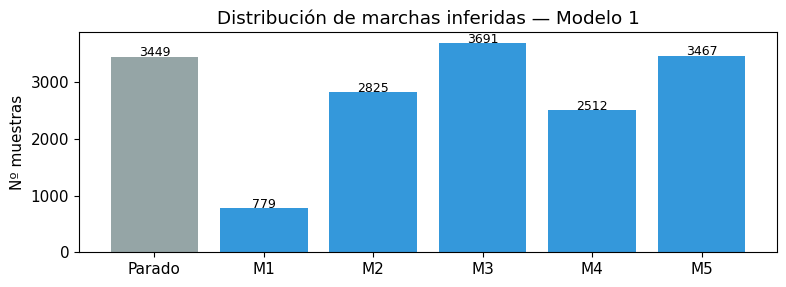

In [ ]:
RATIOS_MARCHA = {1:130, 2:80, 3:55, 4:42, 5:33}

def inferir_marcha(row):
    if row['velocidad'] < 2: return 0
    ratio = row['rpm'] / row['velocidad']
    if ratio > 160: return 0
    return min(RATIOS_MARCHA, key=lambda m: abs(RATIOS_MARCHA[m] - ratio))

df['marcha'] = df.apply(inferir_marcha, axis=1)

print("Distribución de marchas:")
conteo = df['marcha'].value_counts().sort_index()
print(conteo.to_string())

# Advertencia por si alguna marcha tiene muy pocas muestras
for m, n in conteo.items():
    if m > 0 and n < 20:
        print(f"   Marcha {m} solo tiene {n} muestras — puede causar problemas en train/test split")

fig, ax = plt.subplots(figsize=(8, 3))
etiquetas = ['Parado'] + [f'M{i}' for i in range(1,6)]
idx = [i for i in range(6) if i in conteo.index]
ax.bar([etiquetas[i] for i in idx], [conteo[i] for i in idx],
       color=['#95a5a6']+['#3498db']*5)
ax.set_title('Distribución de marchas inferidas — Modelo 1')
ax.set_ylabel('Nº muestras')
for p in ax.patches:
    ax.text(p.get_x()+p.get_width()/2, p.get_height()+3,
            str(int(p.get_height())), ha='center', fontsize=9)
plt.tight_layout(); plt.show()


---
## 5. MODELO – Predicción de marcha (Random Forest)

**Features:** rpm, velocidad, pos_acelerador, carga_motor + extras si disponibles  
**Target:** marcha (1–5, excluye parado/PM para el clasificador supervisado)


In [ ]:
FEATURES_M1       = ['rpm','velocidad','pos_acelerador','ratio_rpm_vel']
TARGET_M1         = 'marcha'

print(f"Features M1: {FEATURES_M1}")

# Solo filas en marcha
df_m1 = df[df['marcha'] > 0].dropna(subset=FEATURES_M1).copy()
X1 = df_m1[FEATURES_M1]
y1 = df_m1[TARGET_M1]

print(f"Muestras M1: {len(df_m1)}")
print(f"Clases presentes: {sorted(y1.unique())}")

# Verificar mínimo de muestras
min_por_clase = y1.value_counts().min()
usar_stratify = min_por_clase >= 5
if not usar_stratify:
    print(f" Clase con solo {min_por_clase} muestra(s) — stratify desactivado")

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42,
    stratify=y1 if usar_stratify else None
)

modelo1 = RandomForestClassifier(n_estimators=200, max_depth=12,
                                  min_samples_leaf=2, random_state=42, n_jobs=-1)
modelo1.fit(X1_train, y1_train)
y1_pred = modelo1.predict(X1_test)
acc_m1  = (y1_pred == y1_test).mean()

labels_presentes = sorted(set(y1_test) | set(y1_pred))
nombres_m1 = [f'M{m}' for m in labels_presentes]

print(f"\n Modelo 1 | Accuracy: {acc_m1:.4f} ({acc_m1*100:.2f}%)")
print()
print(classification_report(y1_test, y1_pred,
                             labels=labels_presentes,
                             target_names=nombres_m1))


Features M1: ['rpm', 'velocidad', 'pos_acelerador', 'ratio_rpm_vel']
Muestras M1: 13274
Clases presentes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]



✅ Modelo 1 | Accuracy: 1.0000 (100.00%)

              precision    recall  f1-score   support

          M1       1.00      1.00      1.00       156
          M2       1.00      1.00      1.00       565
          M3       1.00      1.00      1.00       738
          M4       1.00      1.00      1.00       502
          M5       1.00      1.00      1.00       694

    accuracy                           1.00      2655
   macro avg       1.00      1.00      1.00      2655
weighted avg       1.00      1.00      1.00      2655



Cross-val RF (5-fold): 0.9995 ± 0.0004


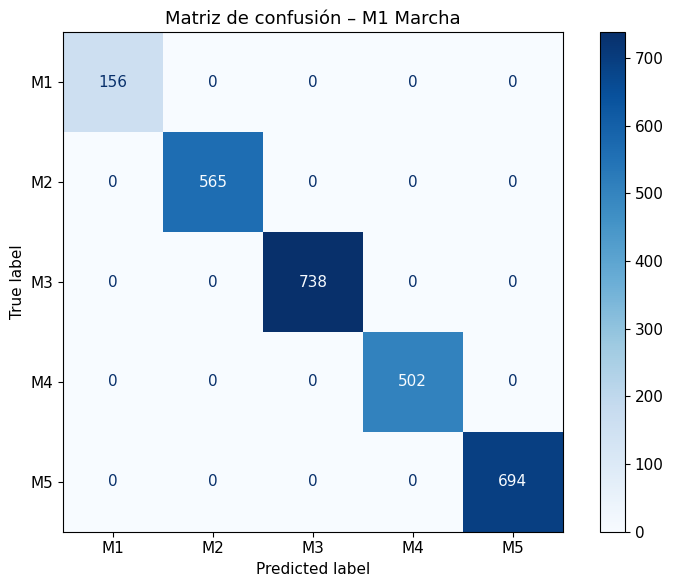

In [10]:
scores_m1 = cross_val_score(modelo1, X1, y1, cv=5, scoring='accuracy', n_jobs=-1)
print(f"Cross-val RF (5-fold): {scores_m1.mean():.4f} ± {scores_m1.std():.4f}")

cm1 = confusion_matrix(y1_test, y1_pred, labels=labels_presentes)
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay(cm1, display_labels=nombres_m1).plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de confusión – M1 Marcha', fontsize=13)
plt.tight_layout(); plt.show()


🔬 Comparativa de algoritmos para M1 (cross-val 5-fold):


  XGBoost     : 0.9951 ± 0.0010


  SVM RBF     : 0.9875 ± 0.0142
  Random Forest: 0.9995 ± 0.0004


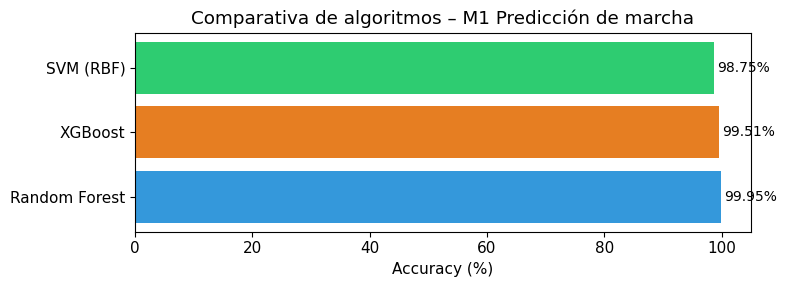


🏆 Mejor M1: Random Forest (99.95%)


In [ ]:
# Comparativa de algoritmos M1
print(" Comparativa de algoritmos para M1 (cross-val 5-fold):")
resultados_m1 = {'Random Forest': scores_m1.mean()}

if XGBOOST_OK:
    le_xgb = LabelEncoder()
    y1_xgb = le_xgb.fit_transform(y1)
    xgb1 = XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1,
                          eval_metric='mlogloss', random_state=42, n_jobs=-1)
    sc_xgb1 = cross_val_score(xgb1, X1, y1_xgb, cv=5, scoring='accuracy', n_jobs=-1)
    resultados_m1['XGBoost'] = sc_xgb1.mean()
    print(f"  XGBoost     : {sc_xgb1.mean():.4f} ± {sc_xgb1.std():.4f}")

sc_svm = StandardScaler()
X1_sc  = sc_svm.fit_transform(X1)
svm1   = SVC(kernel='rbf', C=10, gamma='scale', random_state=42)
sc_svm1 = cross_val_score(svm1, X1_sc, y1, cv=5, scoring='accuracy', n_jobs=-1)
resultados_m1['SVM (RBF)'] = sc_svm1.mean()
print(f"  SVM RBF     : {sc_svm1.mean():.4f} ± {sc_svm1.std():.4f}")
print(f"  Random Forest: {scores_m1.mean():.4f} ± {scores_m1.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 3))
algos = list(resultados_m1.keys())
accs  = list(resultados_m1.values())
bars  = ax.barh(algos, [a*100 for a in accs],
                color=['#3498db','#e67e22','#2ecc71'][:len(algos)])
ax.set_xlabel('Accuracy (%)'); ax.set_xlim(0, 105)
ax.set_title('Comparativa de algoritmos – M1 Predicción de marcha')
for bar, val in zip(bars, accs):
    ax.text(val*100+0.5, bar.get_y()+bar.get_height()/2,
            f'{val*100:.2f}%', va='center', fontsize=10)
plt.tight_layout(); plt.show()
print(f"\n Mejor M1: {max(resultados_m1, key=resultados_m1.get)} "
      f"({max(resultados_m1.values())*100:.2f}%)")


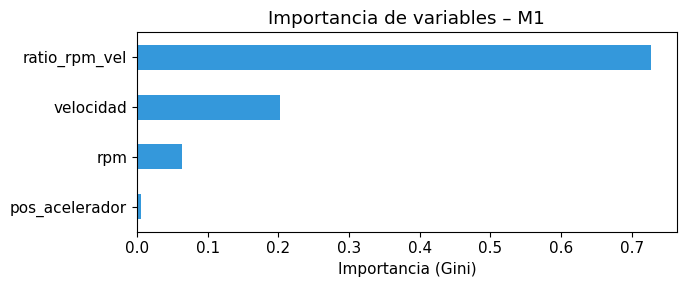

In [12]:
imp1 = pd.Series(modelo1.feature_importances_, index=FEATURES_M1).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 3))
imp1.plot(kind='barh', color='#3498db', ax=ax)
ax.set_title('Importancia de variables – M1')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout(); plt.show()


---
## 7. MODELO – Gemelo digital de temperatura (Gradient Boosting)

**Features:** rpm, velocidad, pos_acelerador, carga_motor, temp_motor + extras  
**Target:** temp_motor N filas adelante (≈ 1 segundo)


In [ ]:
FEATURES_M3       = ['rpm','velocidad','pos_acelerador','temp_motor']
TARGET_M3         = 'temp_futura'

print(f"Features M3: {FEATURES_M3}")

df_m3            = df.dropna(subset=FEATURES_M3).copy()
df_m3[TARGET_M3] = df_m3['temp_motor'].shift(-VENTANA_FILAS)
df_m3            = df_m3.dropna(subset=[TARGET_M3]).reset_index(drop=True)

X3 = df_m3[FEATURES_M3]
y3 = df_m3[TARGET_M3]

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42, shuffle=False
)

scaler3      = StandardScaler()
X3_train_sc  = scaler3.fit_transform(X3_train)
X3_test_sc   = scaler3.transform(X3_test)

modelo3 = GradientBoostingRegressor(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=42
)
modelo3.fit(X3_train_sc, y3_train)
y3_pred = modelo3.predict(X3_test_sc)

mae3  = mean_absolute_error(y3_test, y3_pred)
rmse3 = mean_squared_error(y3_test, y3_pred)**0.5
r2_3  = r2_score(y3_test, y3_pred)

print(f"\n Modelo 3 (ventana = {VENTANA_FILAS} filas ≈ {VENTANA_FILAS/HZ_REAL:.1f}s)")
print(f"   MAE  : {mae3:.4f} °C")
print(f"   RMSE : {rmse3:.4f} °C")
print(f"   R²   : {r2_3:.6f}")


Features M3: ['rpm', 'velocidad', 'pos_acelerador', 'temp_motor']



✅ Modelo 3 (ventana = 3 filas ≈ 1.0s)
   MAE  : 2.3586 °C
   RMSE : 6.0249 °C
   R²   : 0.925594


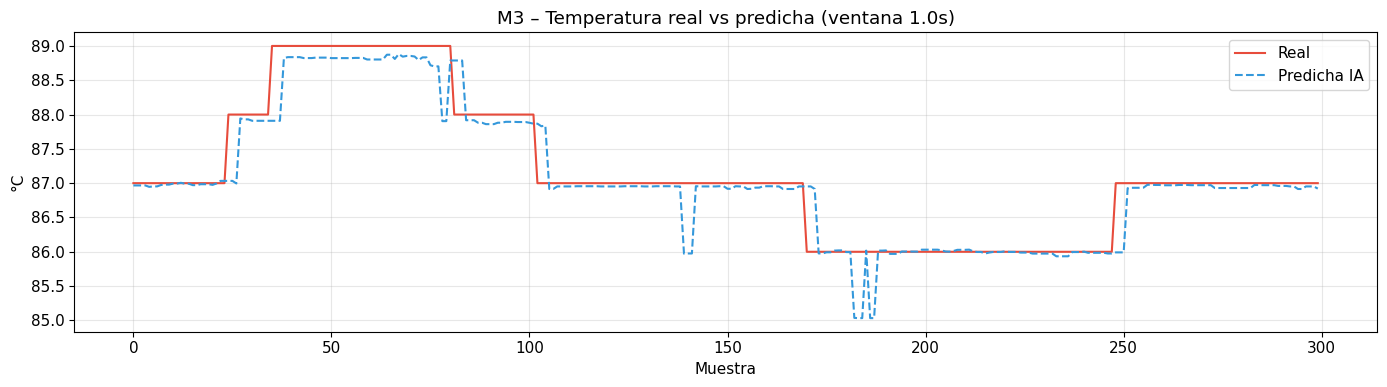

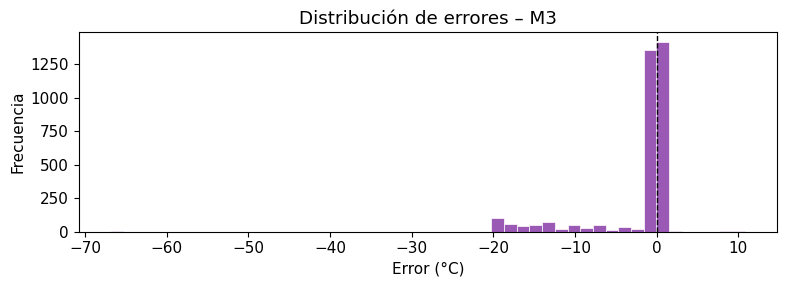

In [14]:
n_plot = min(300, len(y3_test))
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(range(n_plot), y3_test.values[:n_plot], label='Real', color='#e74c3c', linewidth=1.5)
ax.plot(range(n_plot), y3_pred[:n_plot], label='Predicha IA', color='#3498db',
        linewidth=1.5, linestyle='--')
ax.set_xlabel('Muestra'); ax.set_ylabel('°C')
ax.set_title(f'M3 – Temperatura real vs predicha (ventana {VENTANA_FILAS/HZ_REAL:.1f}s)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

errores = y3_test.values - y3_pred
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(errores, bins=50, color='#9b59b6', edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Error (°C)'); ax.set_ylabel('Frecuencia')
ax.set_title('Distribución de errores – M3')
plt.tight_layout(); plt.show()


🔬 Comparativa de algoritmos para M3 (métrica: R²):


  XGBoost           R²: 0.924264


  SVR (RBF)         R²: 0.798403
  Gradient Boosting R²: 0.925594

🏆 Mejor M3: Gradient Boosting


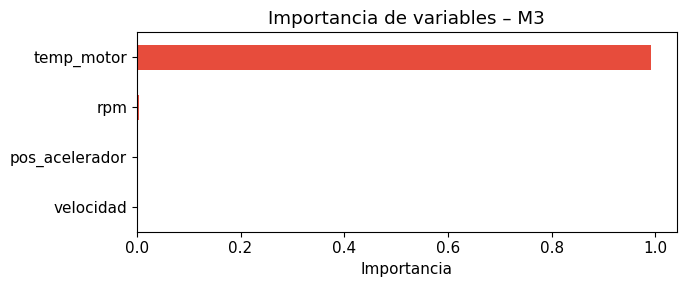

In [ ]:
# Comparativa M3
print(" Comparativa de algoritmos para M3 (métrica: R²):")
resultados_m3 = {'Gradient Boosting': r2_3}

if XGBOOST_OK:
    xgb3 = XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05,
                         subsample=0.8, random_state=42, n_jobs=-1)
    xgb3.fit(X3_train_sc, y3_train)
    r2_xgb3 = r2_score(y3_test, xgb3.predict(X3_test_sc))
    resultados_m3['XGBoost'] = r2_xgb3
    print(f"  XGBoost           R²: {r2_xgb3:.6f}")

svr3 = SVR(kernel='rbf', C=10, epsilon=0.1)
svr3.fit(X3_train_sc, y3_train)
r2_svr3 = r2_score(y3_test, svr3.predict(X3_test_sc))
resultados_m3['SVR (RBF)'] = r2_svr3
print(f"  SVR (RBF)         R²: {r2_svr3:.6f}")
print(f"  Gradient Boosting R²: {r2_3:.6f}")
print(f"\n Mejor M3: {max(resultados_m3, key=resultados_m3.get)}")

imp3 = pd.Series(modelo3.feature_importances_, index=FEATURES_M3).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 3))
imp3.plot(kind='barh', color='#e74c3c', ax=ax)
ax.set_title('Importancia de variables – M3')
ax.set_xlabel('Importancia')
plt.tight_layout(); plt.show()


---
## 10. MODELO – Detección de Anomalías (Isolation Forest)



In [ ]:
# Cargar TODOS los CSVs 
df_list = []
for ruta in RUTAS_CSV:
    try:
        tmp = pd.read_csv(ruta, sep=SEP_CSV)
        tmp.columns = tmp.columns.str.lower().str.strip()
        tmp = tmp.dropna(subset=['rpm'])
        tmp = tmp[tmp['velocidad'] > 2] 
        tmp['trayecto'] = os.path.basename(ruta)
        df_list.append(tmp)
        print(f"   {os.path.basename(ruta)}: {len(tmp)} filas")
    except FileNotFoundError:
        print(f"    No encontrado: {ruta}")

df_all = pd.concat(df_list, ignore_index=True)
df_all['timestamp_iso'] = pd.to_datetime(df_all['timestamp_iso'], errors='coerce')
df_all = df_all.sort_values('timestamp_iso').reset_index(drop=True)
df_all = df_all.ffill()

# solo las que existen en TODOS los CSVs
features_m4 = ['rpm','velocidad','pos_acelerador','temp_motor']

print(f"\nFeatures M4: {features_m4}")
df_anom = df_all.dropna(subset=features_m4).copy()
print(f"Muestras para M4: {len(df_anom)}")


  📂 dataset_skoda_20260327_152347_excel.csv: 0 filas
  📂 dataset_skoda_20260327_223749.csv: 2233 filas
  📂 dataset_skoda_20260328_111925.csv: 1742 filas
  📂 dataset_skoda_20260328_114700.csv: 5098 filas
  📂 dataset_skoda_20260328_193804.csv: 3468 filas
  📂 dataset_skoda_20260329_203706.csv: 0 filas
  📂 dataset_skoda_20260330_184217.csv: 306 filas
  📂 dataset_skoda_20260331_142626.csv: 1415 filas

Features M4: ['rpm', 'velocidad', 'pos_acelerador', 'temp_motor']
Muestras para M4: 14262


Anomalías detectadas en datos de entrenamiento: 1.00%
(esperado ~1% con contamination=0.01)


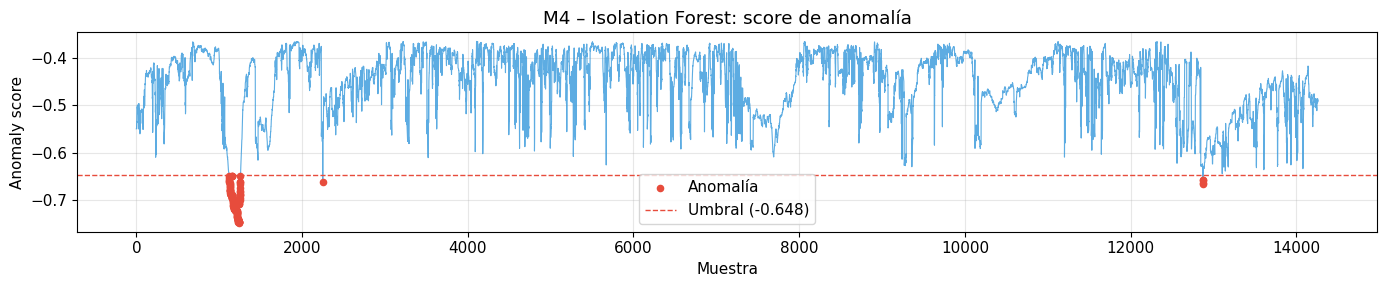

In [ ]:
X_anom    = df_anom[features_m4]
scaler_m4 = StandardScaler()
X_anom_sc = scaler_m4.fit_transform(X_anom)

iso_forest = IsolationForest(contamination=0.01, n_estimators=200, random_state=42)
iso_forest.fit(X_anom_sc)

df_anom = df_anom.copy()
df_anom['anomalia'] = iso_forest.predict(X_anom_sc)   # -1=anomalía, 1=normal
df_anom['score']    = iso_forest.score_samples(X_anom_sc)

ratio = (df_anom['anomalia'] == -1).mean() * 100
print(f"Anomalías detectadas en datos de entrenamiento: {ratio:.2f}%")
print(f"(esperado ~1% con contamination=0.01)")

# Visualizar score de anomalía
fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(df_anom['score'].values, color='#3498db', linewidth=0.8, alpha=0.8)
anomalias_idx = df_anom[df_anom['anomalia']==-1].index
ax.scatter(anomalias_idx, df_anom.loc[anomalias_idx, 'score'],
           color='#e74c3c', s=20, zorder=5, label='Anomalía')
ax.axhline(iso_forest.offset_, color='#e74c3c', linestyle='--',
           linewidth=1, label=f'Umbral ({iso_forest.offset_:.3f})')
ax.set_xlabel('Muestra'); ax.set_ylabel('Anomaly score')
ax.set_title('M4 – Isolation Forest: score de anomalía')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 8. Resumen comparativo

In [18]:
resumen = pd.DataFrame({
    'Modelo':    ['M1 – Marcha', 'M3 – Temperatura', 'M4 – Anomalías'],
    'Tipo':      ['Clasificación', 'Regresión', 'No supervisado'],
    'Algoritmo': ['Random Forest', 'Gradient Boosting', 'Isolation Forest'],
    'Métrica': [
        f'Accuracy: {acc_m1*100:.2f}%',
        f'MAE: {mae3:.3f}°C  R²: {r2_3:.4f}',
        f'Umbral: {iso_forest.offset_:.3f}  Anomalías: {ratio:.1f}%'
    ]
})
print(resumen.to_string(index=False))


          Modelo           Tipo         Algoritmo                         Métrica
     M1 – Marcha  Clasificación     Random Forest               Accuracy: 100.00%
M3 – Temperatura      Regresión Gradient Boosting        MAE: 2.359°C  R²: 0.9256
  M4 – Anomalías No supervisado  Isolation Forest Umbral: -0.648  Anomalías: 1.0%


---
## 9. Exportar modelos

In [ ]:
os.makedirs('../modelos', exist_ok=True)

joblib.dump(modelo1,    '../modelos/modelo1_marcha.pkl')
joblib.dump(modelo3,    '../modelos/modelo3_temperatura.pkl')
joblib.dump(scaler3,    '../modelos/scaler_modelo3.pkl')
joblib.dump(iso_forest, '../modelos/modelo4_anomalia.pkl')
joblib.dump(scaler_m4,  '../modelos/scaler_anomalia.pkl')

print(" Modelos exportados:")
for f in ['modelo1_marcha.pkl','modelo3_temperatura.pkl',
          'scaler_modelo3.pkl','modelo4_anomalia.pkl','scaler_anomalia.pkl']:
    size = os.path.getsize(f'../modelos/{f}')
    print(f"   {f}: {size/1024:.0f} KB")


💾 Modelos exportados:
   modelo1_marcha.pkl: 1258 KB
   modelo3_temperatura.pkl: 392 KB
   scaler_modelo3.pkl: 1 KB
   modelo4_anomalia.pkl: 2349 KB
   scaler_anomalia.pkl: 1 KB
